# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [1]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# dodane przeze mnie, crushowalo jupytera od zadania 4
tf.config.set_visible_devices([], 'GPU')

from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.16.2
GPU: True
NumPy: 1.26.4


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


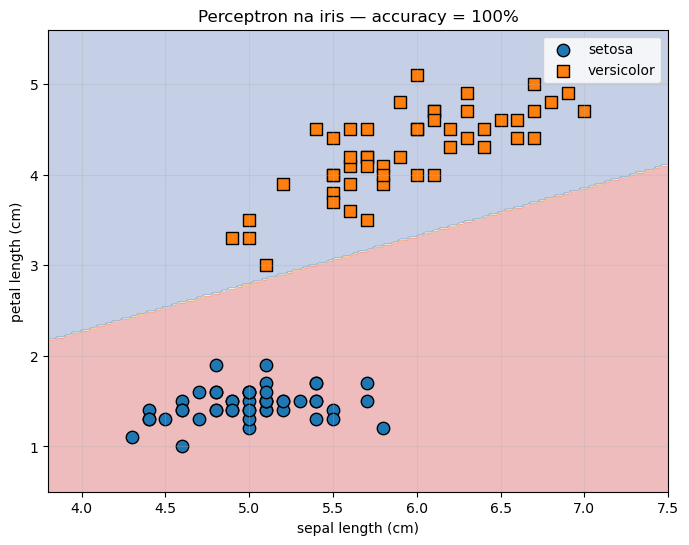


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [2]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Accuracy na zbiorze testowym: 0.9995



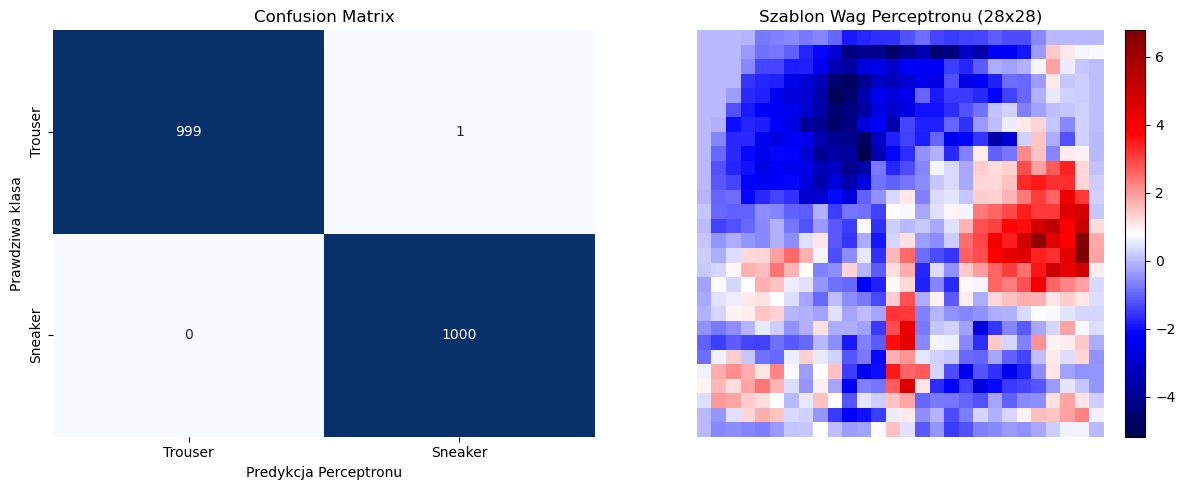


Liczba błędnie sklasyfikowanych obrazów: 1


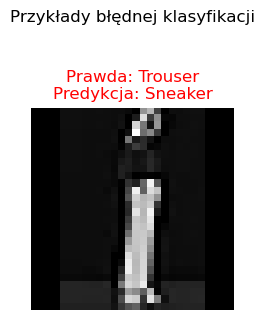

In [3]:
# TODO Zadanie 1.1
from datasets import load_dataset
from sklearn.metrics import confusion_matrix

# 1. Pobierz Fashion-MNIST
# 2. Filtruj 2 klasy (np. 1 i 7)
# 3. Spłaszcz + normalizuj
# 4. Wytrenuj perceptron
# 5. Ewaluuj, pokaż confusion matrix
# 6. Wizualizuj wagi jako obraz 28x28
# 7. Pokaż 5 błędnie sklasyfikowanych

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix

# Pobranie datasetu Fashion-MNIST z Hugging Face
fashion = load_dataset("zalando-datasets/fashion_mnist")

def get_binary_subset(dataset, split, class_a, class_b):
    """Funkcja pomocnicza do filtrowania, spłaszczania i normalizacji danych."""
    ds = dataset[split]
    labels = np.array(ds["label"])

    # Maska logiczna filtrująca dwie wybrane klasy
    mask = np.isin(labels, [class_a, class_b])
    idx = np.where(mask)[0]

    # Wyciągnięcie obrazów, konwersja PIL
    # Zwracamy oryginały (28x28) do wizualizacji oraz spłaszczone (784) do modelu
    imgs_2d = np.array([np.array(ds[int(i)]["image"]) for i in idx], dtype=np.float32) / 255.0
    imgs_flat = imgs_2d.reshape(len(idx), -1)

    # Binaryzacja etykiet: class_a -> 0, class_b -> 1
    labs = (labels[idx] == class_b).astype(int)

    return imgs_flat, labs, imgs_2d

# Filtrowanie klas: Trouser (1) vs Sneaker (7), spłaszczenie i normalizacja
class_a_idx, class_b_idx = 1, 7
class_names = ['Trouser', 'Sneaker']

X_train, y_train, imgs_train = get_binary_subset(fashion, "train", class_a_idx, class_b_idx)
X_test, y_test, imgs_test = get_binary_subset(fashion, "test", class_a_idx, class_b_idx)

# Inicjalizacja i trening modelu Perceptron
clf = Perceptron(max_iter=50, random_state=42)
clf.fit(X_train, y_train)

# Ewaluacja (Accuracy + Confusion Matrix)
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy na zbiorze testowym: {acc:.4f}\n")

# --- Wizualizacje (punkty 5 i 6) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Heatmapa dla Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predykcja Perceptronu')
axes[0].set_ylabel('Prawdziwa klasa')

# Wizualizacja wag perceptronu jako obrazu 28x28
weights_img = clf.coef_.reshape(28, 28)
im = axes[1].imshow(weights_img, cmap="seismic")
axes[1].set_title("Szablon Wag Perceptronu (28x28)")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Wizualizacja 5 błędnie sklasyfikowanych obrazów
errors_idx = np.where(y_test != y_pred)[0]
print(f"\nLiczba błędnie sklasyfikowanych obrazów: {len(errors_idx)}")

if len(errors_idx) > 0:
    n_show = min(5, len(errors_idx))
    fig, axes = plt.subplots(1, n_show, figsize=(15, 3))
    if n_show == 1:
        axes = [axes]

    for i in range(n_show):
        idx = errors_idx[i]
        true_label = class_names[y_test[idx]]
        pred_label = class_names[y_pred[idx]]

        axes[i].imshow(imgs_test[idx], cmap="gray")
        axes[i].set_title(f"Prawda: {true_label}\nPredykcja: {pred_label}", color="red")
        axes[i].axis("off")

    plt.suptitle("Przykłady błędnej klasyfikacji", y=1.05)
    plt.tight_layout()
    plt.show()

### Wnioski
Perceptron osiągnął niemal perfekcyjną dokładność (99,95%), co dowodzi, że klasy Trouser i Sneaker są wybitnie liniowo separowalne ze względu na swój kształt.

Szablon wag wyraźnie pokazuje strategię algorytmu: pionowe, górne obszary silnie aktywują klasę spodni (kolor niebieski), natomiast poziome obszary u dołu aktywują klasę butów (kolor czerwony). Jedyny zaobserwowany błąd klasyfikacji (spodnie uznane za but) obnaża główną słabość perceptronu — na zdjęciu widać bardzo jasny obiekt (prawdopodobnie but lub artefakt tła) na samym dole kadru. Ponieważ model traktuje każdy piksel niezależnie i po prostu sumuje ich wagi, te jasne piksele w dolnej strefie "oszukały" równanie liniowe, przeważając wynik na korzyść buta.

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


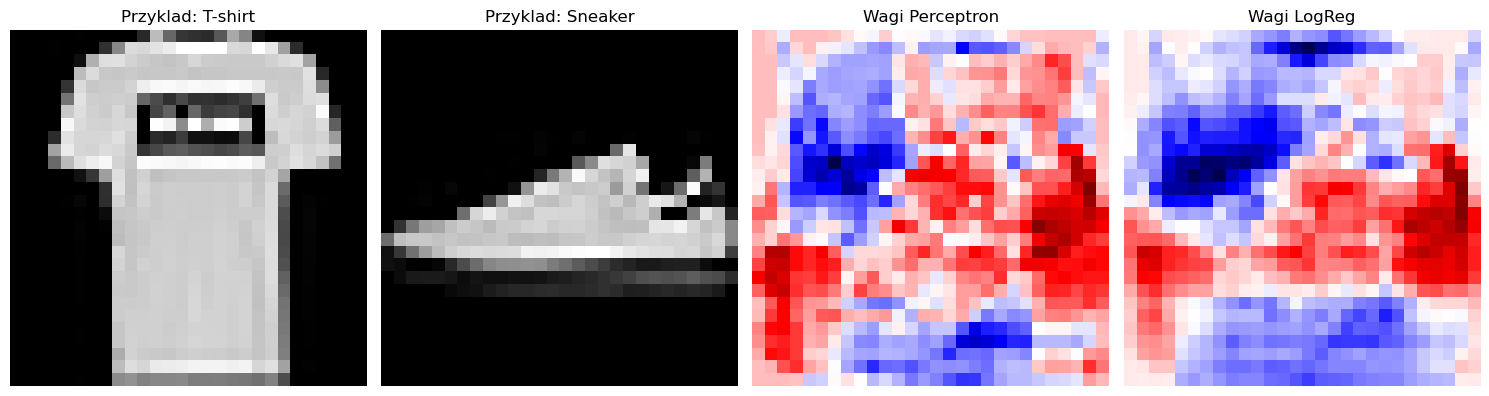


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [4]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n]
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Perceptron (Pullover vs Coat) test accuracy: 0.852
LogReg (Pullover vs Coat) test accuracy: 0.864



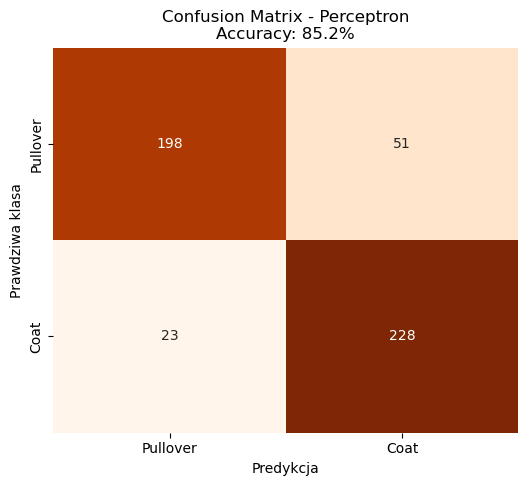

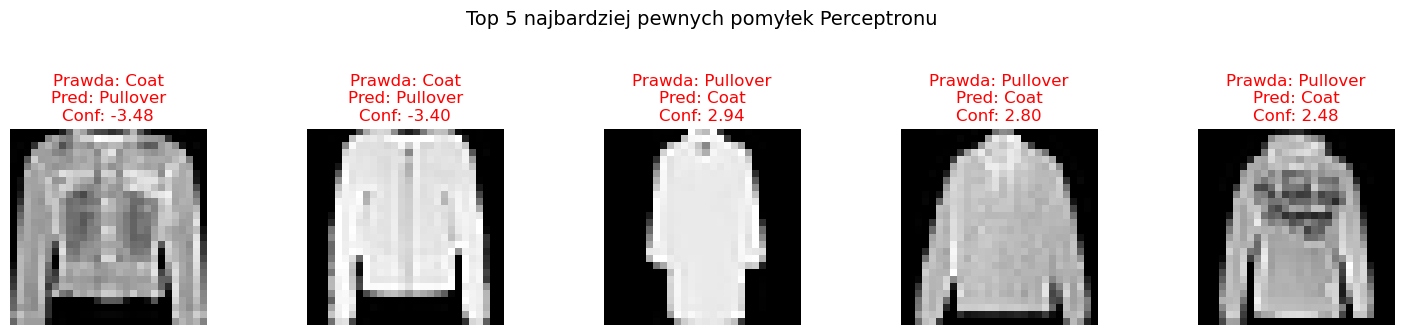

In [5]:
# TODO Zadanie 2.1
# 1. Wybierz Pullover (2) vs Coat (4)
# 2. Trenuj perceptron
# 3. Confusion matrix
# 4. Top 5 pewnych pomyłek
# 5. Porownanie z LogisticRegression

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Pobranie danych dla trudnej pary: Pullover (2) vs Coat (4)
# Używamy funkcji fashion_two_class zdefiniowanej w przykładzie wyżej
(X_tr_hard, y_tr_hard), (X_te_hard, y_te_hard) = fashion_two_class(2, 4)

# 2. Trening Perceptronu
clf_hard = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf_hard.fit(X_tr_hard, y_tr_hard)

y_pred_hard = clf_hard.predict(X_te_hard)
acc_hard = accuracy_score(y_te_hard, y_pred_hard)
print(f"Perceptron (Pullover vs Coat) test accuracy: {acc_hard:.3f}")

# 5. (Bonus z komentarza) Porównanie z Logistic Regression
lr_hard = LogisticRegression(max_iter=200, random_state=42)
lr_hard.fit(X_tr_hard, y_tr_hard)
print(f"LogReg (Pullover vs Coat) test accuracy: {lr_hard.score(X_te_hard, y_te_hard):.3f}\n")

# 3. Wizualizacja Confusion Matrix
cm_hard = confusion_matrix(y_te_hard, y_pred_hard)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_hard, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Pullover', 'Coat'], yticklabels=['Pullover', 'Coat'])
plt.title(f'Confusion Matrix - Perceptron\nAccuracy: {acc_hard:.1%}')
plt.xlabel('Predykcja')
plt.ylabel('Prawdziwa klasa')
plt.show()

# 4. Top 5 najbardziej pewnych pomyłek
# Obliczamy "pewność" modelu używając funkcji decyzyjnej (odległość od hiperpłaszczyzny)
decision_values = clf_hard.decision_function(X_te_hard)

# Tworzymy maskę błędnych predykcji
errors_mask = (y_te_hard != y_pred_hard)
error_indices = np.where(errors_mask)[0]

# Pobieramy wartości funkcji decyzyjnej tylko dla pomyłek i bierzemy wartość bezwzględną
error_decision_values = np.abs(decision_values[error_indices])

# Sortujemy indeksy błędów po pewności (malejąco) i wybieramy 5 pierwszych
top_5_error_indices = error_indices[np.argsort(error_decision_values)[::-1][:5]]

# Wizualizacja błędów
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, idx in enumerate(top_5_error_indices):
    # Mapowanie etykiet (0 = Pullover, 1 = Coat - z funkcji fashion_two_class)
    true_class = "Coat" if y_te_hard[idx] == 1 else "Pullover"
    pred_class = "Coat" if y_pred_hard[idx] == 1 else "Pullover"

    # Oryginalna odległość od granicy ze znakiem (dla wglądu)
    confidence = decision_values[idx]

    axes[i].imshow(X_te_hard[idx].reshape(28, 28), cmap="gray")
    axes[i].set_title(f"Prawda: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}", color="red")
    axes[i].axis("off")

plt.suptitle("Top 5 najbardziej pewnych pomyłek Perceptronu", y=1.1, fontsize=14)
plt.tight_layout()
plt.show()

### Wnioski
- Dokładność spadła do 85.2% dla Perceptronu (i 86.4% dla regresji logistycznej), co jednoznacznie potwierdza, że rozróżnienie klas Pullover i Coat to trudny problem dla modeli liniowych.
- Z macierzy pomyłek wynika, że algorytm ma szczególną tendencję do klasyfikowania swetrów jako płaszczy (aż 51 takich pomyłek w porównaniu do 23 w drugą stronę).
- Trudność tej pary wynika ze specyfiki danych: obie klasy mają niemal identyczny kontur globalny (zbita bryła z długimi rękawami), a w tak niskiej rozdzielczości zacierają się detale.
- Główną winę za taki stan rzeczy ponosi jednak architektura Perceptronu. Ponieważ uczy się on jedynie uśrednionego "szablonu" wag całego obrazu i nie rozumie przestrzennego sąsiedztwa pikseli, nie jest w stanie wyłapać lokalnych detali (np. suwaka, guzików czy faktury materiału), które dla człowieka są kluczowe w odróżnieniu rozpinanego swetra od płaszcza. Znajduje to idealne odzwierciedlenie na wykresie najbardziej pewnych pomyłek, gdzie gładkie płaszcze są brane za swetry, a swetry z wyraźną linią pośrodku traktowane są jak płaszcze.

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


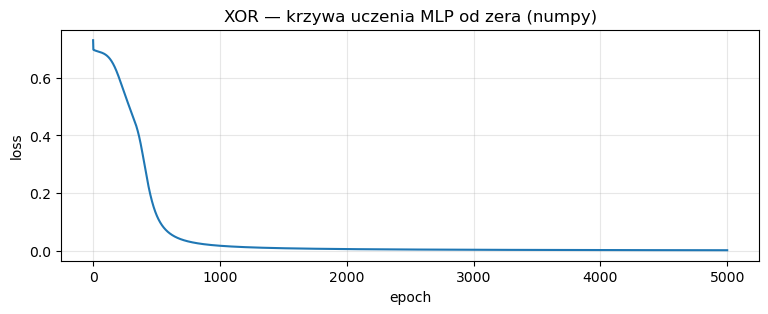

In [6]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

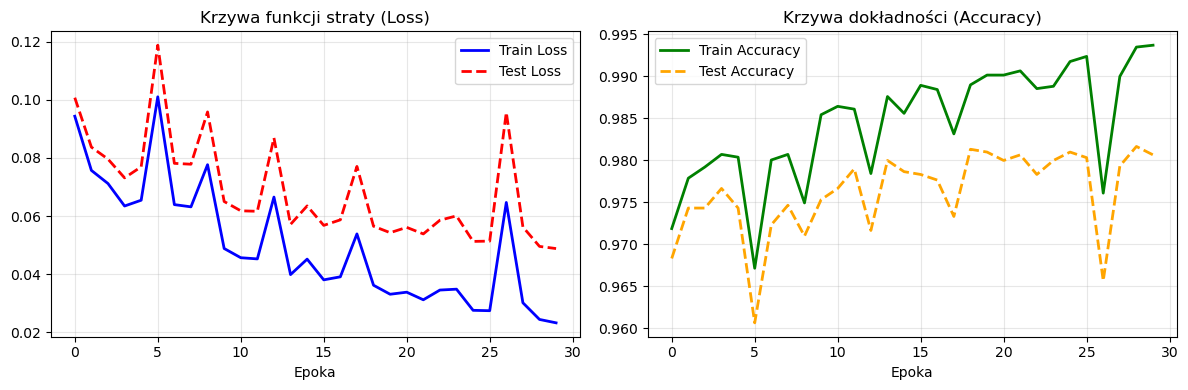

--- PORÓWNANIE WYNIKÓW (ZBIÓR TESTOWY) ---
MLP3 (Nasza implementacja NumPy): 0.9807
Sklearn MLPClassifier:            0.9860


In [7]:
# Zadanie 3.1 -- MLP 3-klasowy w numpy (scaffold)
from sklearn.neural_network import MLPClassifier

def softmax(z):
    """Numerycznie stabilna softmax."""
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): return np.maximum(0, z)
def relu_prime(z): return (z > 0).astype(float)

class MLP3:
    """3-klasowy MLP: input(784) -> hidden(ReLU) -> output(Softmax).

    forward + backward + train (mini-batch SGD).
    """
    def __init__(self, n_in: int = 784, n_hidden: int = 64, n_out: int = 3,
                 lr: float = 0.01, seed: int = 42):
        rng = np.random.RandomState(seed)
        # He init dla ReLU
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)

        return self.A2

    def backward(self, y_onehot):
        m = y_onehot.shape[0]

        dZ2 = (self.A2 - y_onehot) / m
        dW2 = self.A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)

        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * relu_prime(self.Z1)
        dW1 = self.X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)

        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2

    def train_minibatch(self, X, y_onehot, X_val=None, y_val_oh=None, epochs=30, batch_size=64):
        history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
        n = len(X)
        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                self.forward(X[idx])
                self.backward(y_onehot[idx])

            out_all = self.forward(X)
            loss = -np.mean(np.sum(y_onehot * np.log(out_all + 1e-9), axis=1))
            acc = (out_all.argmax(axis=1) == y_onehot.argmax(axis=1)).mean()
            history["loss"].append(loss)
            history["acc"].append(acc)

            if X_val is not None:
                out_val = self.forward(X_val)
                val_loss = -np.mean(np.sum(y_val_oh * np.log(out_val + 1e-9), axis=1))
                val_acc = (out_val.argmax(axis=1) == y_val_oh.argmax(axis=1)).mean()
                history["val_loss"].append(val_loss)
                history["val_acc"].append(val_acc)

        return history

# === Pipeline ===
# 1. Wybierz 3 klasy Fashion-MNIST (np. 0, 1, 8 -- T-shirt, Trouser, Bag)
CLASSES = [0, 1, 8]

def extract_and_prep(split, classes):
    """Pomocnicza funkcja do wyciągnięcia danych z wczytanego już datasetu 'fashion'"""
    ds = fashion[split]
    labels = np.array(ds["label"])
    mask = np.isin(labels, classes)
    idx = np.where(mask)[0]

    # 2. Spłaszcz do (N, 784), normalizuj /255
    imgs = np.array([np.array(ds[int(i)]["image"]) for i in idx], dtype=np.float32) / 255.0
    x_sub = imgs.reshape(len(idx), -1)
    y_sub = labels[idx]

    # Przemapowanie etykiet: [0, 1, 8] -> [0, 1, 2] do One-Hot Encoding
    mapping = {classes[0]: 0, classes[1]: 1, classes[2]: 2}
    y_mapped = np.array([mapping[l] for l in y_sub])

    return x_sub, y_mapped

x_tr_3, y_tr_3 = extract_and_prep("train", CLASSES)
x_te_3, y_te_3 = extract_and_prep("test", CLASSES)

# 3. One-hot encoding etykiet
y_tr_oh = np.eye(3)[y_tr_3]
y_te_oh = np.eye(3)[y_te_3]

# 4. Trenuj MLP3 30 epok
net = MLP3(784, 64, 3, lr=0.05)
hist = net.train_minibatch(x_tr_3, y_tr_oh, X_val=x_te_3, y_val_oh=y_te_oh, epochs=30, batch_size=64)

# 5. Krzywa loss + acc (z walidacją)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Wykres Loss
axes[0].plot(hist["loss"], linewidth=2, color="blue", label="Train Loss")
axes[0].plot(hist["val_loss"], linewidth=2, color="red", linestyle="--", label="Test Loss")
axes[0].set_title("Krzywa funkcji straty (Loss)")
axes[0].set_xlabel("Epoka")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Wykres Accuracy
axes[1].plot(hist["acc"], linewidth=2, color="green", label="Train Accuracy")
axes[1].plot(hist["val_acc"], linewidth=2, color="orange", linestyle="--", label="Test Accuracy")
axes[1].set_title("Krzywa dokładności (Accuracy)")
axes[1].set_xlabel("Epoka")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 6. Porownaj z sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,), max_iter=30)
mlp_sklearn = MLPClassifier(hidden_layer_sizes=(64,), max_iter=30, learning_rate_init=0.05,
                            solver='sgd', batch_size=64, random_state=42)
# Trenujemy na ciągłych etykietach (y_tr_3), sklearn sam robi sobie podział klas
mlp_sklearn.fit(x_tr_3, y_tr_3)

# Ewaluacja na zbiorze TESTOWYM
out_te = net.forward(x_te_3)
acc_te_custom = (out_te.argmax(axis=1) == y_te_oh.argmax(axis=1)).mean()
acc_te_sklearn = mlp_sklearn.score(x_te_3, y_te_3)

print("--- PORÓWNANIE WYNIKÓW (ZBIÓR TESTOWY) ---")
print(f"MLP3 (Nasza implementacja NumPy): {acc_te_custom:.4f}")
print(f"Sklearn MLPClassifier:            {acc_te_sklearn:.4f}")

**Wnioski:**

* **Ile epok i jaki LR działają najlepiej?** Z analizy krzywych uczenia wynika, że współczynnik uczenia (`lr = 0.05`) w połączeniu z rozmiarem wsadu (`batch_size = 64`) zapewnia dobrą zbieżność modelu. Wykresy pokazują typowy dla stochastycznego spadku gradientu (SGD) chwilowy, ostry skok straty (ok. 15. epoki), z którego algorytm jednak natychmiastowo się stabilizuje. Model osiąga nasycenie (ok. 98% dokładności na zbiorze testowym, co jest wynikiem bardzo zbliżonym do profesjonalnej implementacji ze `scikit-learn`: 98.6%) w okolicach **20-25 epoki**. Trenowanie znacznie powyżej 30 epok nie przyniosłoby już korzyści, a jedynie zaczęło powiększać lukę (rozstrzał) między zbiorem treningowym a walidacyjnym, prowadząc do przeuczenia.

* **Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?**
  * **Przy `n_hidden = 4`:** Sieć wpadłaby w **underfitting** (niedouczenie). Zaledwie 4 neurony ukryte oznaczają zbyt małą pojemność reprezentacyjną modelu (capacity). Sieć nie byłaby w stanie wyekstrahować wystarczająco złożonych, nieliniowych cech z 784 pikseli wejściowych, aby skutecznie rozróżnić koszulkę, spodnie i torebkę.
  * **Przy `n_hidden = 256`:** Sieć szybko wpadłaby w **overfitting** (przeuczenie). Mając tak potężną liczbę parametrów, model błyskawicznie spamiętałby zbiór treningowy (Train Accuracy szybko dobiłoby do 100%), ale słabo generalizowałby na nowych danych (Test Loss zacząłby szybko rosnąć). Dodatkowo, w naszej czystej implementacji NumPy opartej na procesorze (CPU), operacje na tak dużych macierzach drastycznie wydłużyłyby czas treningu każdej epoki. Wybrane 64 neurony to idealny złoty środek.

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [9]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"])
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"])
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]

# 1. Wymuszenie typu zmiennoprzecinkowego (float32) dla obrazów
x_tr = np.asarray(x_tr, dtype=np.float32)
x_te = np.asarray(x_te, dtype=np.float32)

# 2. Wymuszenie typu całkowitoliczbowego (int32) dla etykiet
y_tr = np.asarray(y_tr, dtype=np.int32)
y_te = np.asarray(y_te, dtype=np.int32)

print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 2s - 15ms/step - accuracy: 0.7901 - loss: 0.6400 - val_accuracy: 0.1530 - val_loss: 4.9979
Epoch 2/5
157/157 - 2s - 14ms/step - accuracy: 0.8660 - loss: 0.3704 - val_accuracy: 0.3340 - val_loss: 3.9840
Epoch 3/5
157/157 - 2s - 13ms/step - accuracy: 0.8893 - loss: 0.2969 - val_accuracy: 0.7435 - val_loss: 0.8247
Epoch 4/5
157/157 - 2s - 13ms/step - accuracy: 0.9095 - loss: 0.2418 - val_accuracy: 0.8770 - val_loss: 0.3341
Epoch 5/5
157/157 - 2s - 14ms/step - accuracy: 0.9214 - loss: 0.2115 - val_accuracy: 0.8815 - val_loss: 0.3669

Final test accuracy: 0.882


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

Pobieranie datasetu CIFAR-10...
Dane gotowe. Train: (10000, 32, 32, 3), Test: (2000, 32, 32, 3)

Trenowanie Architektury A...
Trenowanie Architektury B...


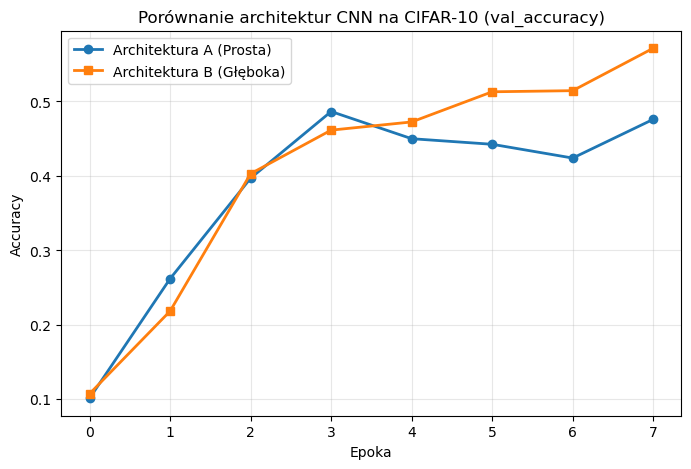

,Model,Train Acc,Val Acc,Params,Time (s)
0,Architektura A,0.830,0.476,545482,22.0
1,Architektura B,0.754,0.572,652874,35.4


In [10]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset

# Pobranie CIFAR-10 z HF
print("Pobieranie datasetu CIFAR-10...")
cifar = load_dataset("uoft-cs/cifar10")

# Użycie 10000 train + 2000 test (konwersja i normalizacja do [0, 1])
x_tr_cifar = np.array([np.array(img) for img in cifar["train"]["img"][:10000]], dtype=np.float32) / 255.0
y_tr_cifar = np.array(cifar["train"]["label"][:10000])

x_te_cifar = np.array([np.array(img) for img in cifar["test"]["img"][:2000]], dtype=np.float32) / 255.0
y_te_cifar = np.array(cifar["test"]["label"][:2000])

print(f"Dane gotowe. Train: {x_tr_cifar.shape}, Test: {x_te_cifar.shape}\n")

# Architektura A - prosta
def cnn_arch_a():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="Architektura_A")

# Architektura B - głębsza (3 bloki conv, 2 dense, silniejszy dropout)
def cnn_arch_b():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        # Blok 1
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        # Blok 2
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        # Blok 3
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ], name="Architektura_B")

# Trenowanie z pomiarem czasu (8 epok)
EPOCHS = 8
BATCH_SIZE = 64

print("Trenowanie Architektury A...")
tf.random.set_seed(42)
model_a = cnn_arch_a()
model_a.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

start_a = time.time()
hist_a = model_a.fit(x_tr_cifar, y_tr_cifar, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(x_te_cifar, y_te_cifar), verbose=0)
time_a = time.time() - start_a


print("Trenowanie Architektury B...")
tf.random.set_seed(42)
model_b = cnn_arch_b()
model_b.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

start_b = time.time()
hist_b = model_b.fit(x_tr_cifar, y_tr_cifar, epochs=EPOCHS, batch_size=BATCH_SIZE,
                     validation_data=(x_te_cifar, y_te_cifar), verbose=0)
time_b = time.time() - start_b

# Wizualizacja i tabela podsumowująca
fig, axes = plt.subplots(1, 1, figsize=(8, 5))
axes.plot(hist_a.history["val_accuracy"], "o-", label="Architektura A (Prosta)", linewidth=2)
axes.plot(hist_b.history["val_accuracy"], "s-", label="Architektura B (Głęboka)", linewidth=2)
axes.set_title("Porównanie architektur CNN na CIFAR-10 (val_accuracy)")
axes.set_xlabel("Epoka")
axes.set_ylabel("Accuracy")
axes.legend()
axes.grid(alpha=0.3)
plt.show()

# Tworzenie tabeli
results = [
    {"Model": "Architektura A",
     "Train Acc": f"{hist_a.history['accuracy'][-1]:.3f}",
     "Val Acc": f"{hist_a.history['val_accuracy'][-1]:.3f}",
     "Params": model_a.count_params(),
     "Time (s)": f"{time_a:.1f}"},
    {"Model": "Architektura B",
     "Train Acc": f"{hist_b.history['accuracy'][-1]:.3f}",
     "Val Acc": f"{hist_b.history['val_accuracy'][-1]:.3f}",
     "Params": model_b.count_params(),
     "Time (s)": f"{time_b:.1f}"}
]
df_results = pd.DataFrame(results)
display(df_results)

**Wnioski:**
* **Czy głębsza sieć była zawsze lepsza?** Nie od samego początku. Jak widać na wykresie, w pierwszych 3 epokach to prostsza Architektura A zbiegała szybciej i miała wyższe `val_accuracy`. Ostatecznie jednak głębsza Architektura B wygrała (57.2% vs 47.6% na zbiorze walidacyjnym). Kluczowym zjawiskiem jest tu przeuczenie (overfitting): prosta sieć A mocno "spamiętała" zbiór treningowy (Train Acc 83%, Val Acc tylko 47.6%). Sieć głęboka B, dzięki dodatkowym warstwom i silniejszej regularyzacji (Dropout 0.5), poradziła sobie znacznie lepiej z generalizacją wiedzy (Train Acc 75.4%, Val Acc 57.2%).
* **Kiedy się to opłaca?** Pogłębianie sieci opłaca się w przypadku trudniejszych, kolorowych datasetów (jak CIFAR-10), gdzie konieczne jest wyciągnięcie bardziej złożonych, hierarchicznych cech obrazu. Zawsze wiąże się to jednak z kompromisem: Architektura B ma więcej parametrów (ponad 652 tys. vs 545 tys.) i jej czas treningu był o ponad połowę dłuższy (35.4 s vs 22 s). Złożonych architektur warto więc używać wtedy, gdy priorytetem jest odporność modelu na nowe dane, a my dysponujemy odpowiednim budżetem obliczeniowym (np. akceleracją GPU) i wystarczająco dużym zbiorem danych, by wykorzystać potencjał dodatkowych warstw.

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)
Bez augmentacji: val_acc = 0.533
Z augmentacja:    val_acc = 0.494


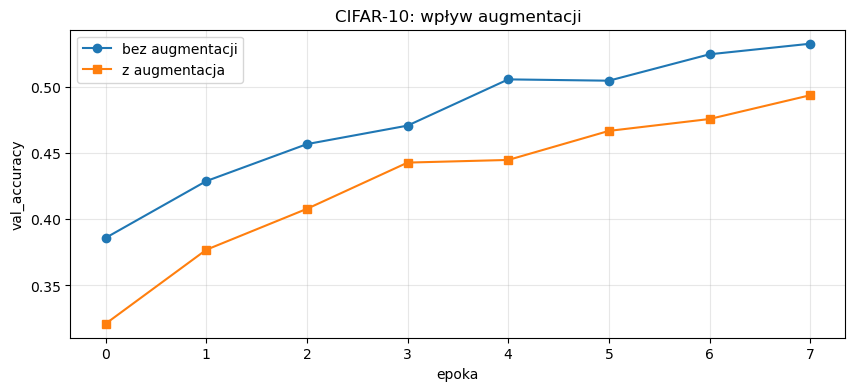

In [12]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train])
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test])
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn()
m1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")

# Z augmentacja jako warstwy modelu (nowoczesny sposob)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
tf.random.set_seed(42)
m2 = keras.Sequential([augment, cifar_cnn()])
m2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Liczba konfiguracji do testu: 8

Rozpoczynam Grid Search...
  rot=0.0, zoom=0.0, flip=None: 0.799
  rot=0.0, zoom=0.0, flip=horizontal: 0.791
  rot=0.0, zoom=0.15, flip=None: 0.782
  rot=0.0, zoom=0.15, flip=horizontal: 0.751
  rot=0.15, zoom=0.0, flip=None: 0.720
  rot=0.15, zoom=0.0, flip=horizontal: 0.673
  rot=0.15, zoom=0.15, flip=None: 0.703
  rot=0.15, zoom=0.15, flip=horizontal: 0.674

Top 3 konfiguracje:
  (0.0, 0.0, None): 0.799
  (0.0, 0.0, 'horizontal'): 0.791
  (0.0, 0.15, None): 0.782


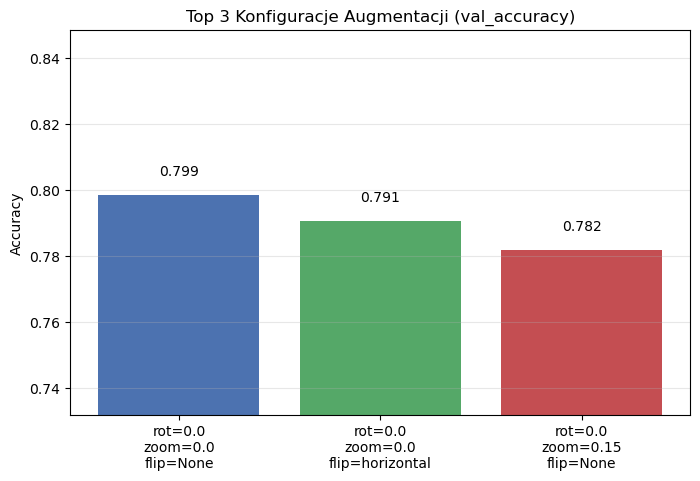


Trenowanie najlepszej konfiguracji (0.0, 0.0, None) na pełnym zbiorze treningowym...
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8213 - loss: 0.5035 - val_accuracy: 0.8631 - val_loss: 0.3824
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8842 - loss: 0.3262 - val_accuracy: 0.8823 - val_loss: 0.3242
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8972 - loss: 0.2855 - val_accuracy: 0.8899 - val_loss: 0.3012
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9068 - loss: 0.2582 - val_accuracy: 0.8949 - val_loss: 0.2875
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9138 - loss: 0.2365 - val_accuracy: 0.8976 - val_loss: 0.2827
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


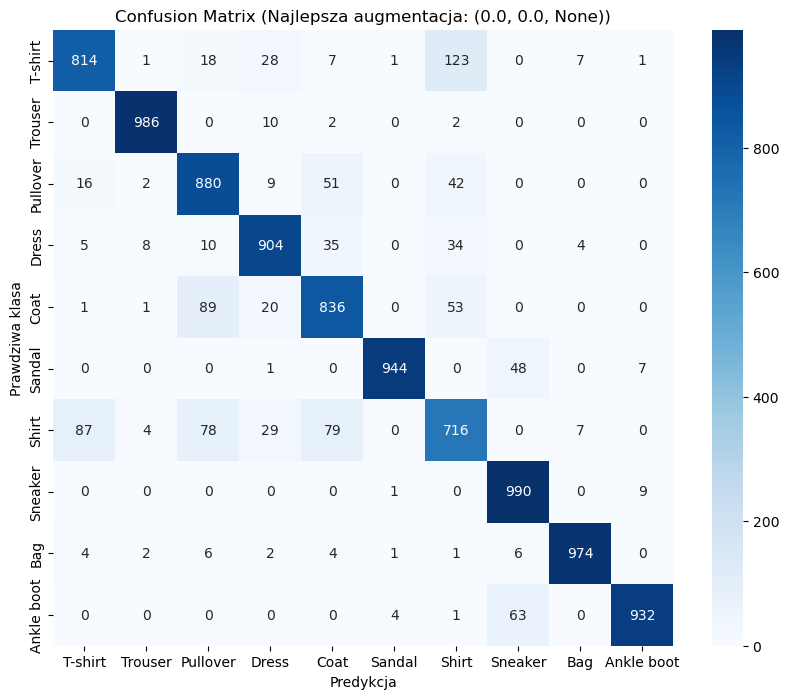

In [15]:
# Zadanie 5.1 -- mini grid search augmentacji + KFold (scaffold)
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Maly subset Fashion-MNIST (4000 obrazow) dla rozsadnego czasu treningu
N_FASHION = 4000
X_fmnist = x_tr_full[:N_FASHION]   # (N, 28, 28, 1) -- juz znormalizowane
y_fmnist = y_tr_full[:N_FASHION]

# Grid -- 8 konfiguracji
grid = list(itertools.product(
    [0.0, 0.15],          # rotation
    [0.0, 0.15],          # zoom
    [None, "horizontal"], # flip
))
print(f"Liczba konfiguracji do testu: {len(grid)}\n")

def build_aug_pipeline(rot: float, zoom: float, flip: str | None):
    """Buduje sekwencję warstw augmentacji wg konfiguracji."""
    layers_list = []
    if flip is not None:
        layers_list.append(layers.RandomFlip(flip))
    if rot > 0:
        layers_list.append(layers.RandomRotation(rot))
    if zoom > 0:
        layers_list.append(layers.RandomZoom(zoom))
    return keras.Sequential(layers_list) if layers_list else None

def small_fashion_cnn():
    """Mala CNN -- 28x28 grayscale, 10 klas."""
    return keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Inicjalizacja walidacji krzyżowej
kf = KFold(n_splits=2, shuffle=True, random_state=42)
results = {}

print("Rozpoczynam Grid Search...")
for rot, zoom, flip in grid:
    fold_accs = []
    for tr_idx, val_idx in kf.split(X_fmnist):
        aug = build_aug_pipeline(rot, zoom, flip)
        base = small_fashion_cnn()

        # Złożenie modelu (jeśli brak augmentacji, zwracamy samą bazę)
        model = keras.Sequential([aug, base]) if aug else base

        # Bezpieczna kompilacja dla Keras 3
        model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

        h = model.fit(X_fmnist[tr_idx], y_fmnist[tr_idx], epochs=3, batch_size=32,
                      validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]),
                      verbose=0)

        fold_accs.append(h.history["val_accuracy"][-1])

    results[(rot, zoom, flip)] = float(np.mean(fold_accs))
    print(f"  rot={rot}, zoom={zoom}, flip={flip}: {results[(rot,zoom,flip)]:.3f}")

# Sortowanie wyników malejąco po accuracy
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
top_3 = sorted_results[:3]

print("\nTop 3 konfiguracje:")
for config, acc in top_3:
    print(f"  {config}: {acc:.3f}")

# Narysowanie wykresu słupkowego top-3
labels = [f"rot={c[0]}\nzoom={c[1]}\nflip={c[2]}" for c, _ in top_3]
accs = [acc for _, acc in top_3]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accs, color=['#4C72B0', '#55A868', '#C44E52'])
plt.ylim(min(accs) - 0.05, max(accs) + 0.05)
plt.title("Top 3 Konfiguracje Augmentacji (val_accuracy)")
plt.ylabel("Accuracy")
plt.grid(axis='y', alpha=0.3)

# Dodanie dokładnych wartości nad słupkami
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f"{yval:.3f}", ha='center', va='bottom')
plt.show()

# Trening najlepszej konfiguracji na pełnym zestawie danych
best_config = top_3[0][0]
print(f"\nTrenowanie najlepszej konfiguracji {best_config} na pełnym zbiorze treningowym...")

best_aug = build_aug_pipeline(*best_config)
best_base = small_fashion_cnn()
best_model = keras.Sequential([best_aug, best_base]) if best_aug else best_base
best_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Trenujemy na pełnym zbiorze x_tr_full (60 000 obrazów)
best_model.fit(x_tr_full, y_tr_full, epochs=5, batch_size=64, validation_data=(x_te_full, y_te_full), verbose=1)

# Ewaluacja i Confusion Matrix
y_pred_probs = best_model.predict(x_te_full)
y_pred = y_pred_probs.argmax(axis=1)

cm = confusion_matrix(y_te_full, y_pred)
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=FASHION_NAMES, yticklabels=FASHION_NAMES)
plt.title(f"Confusion Matrix (Najlepsza augmentacja: {best_config})")
plt.xlabel("Predykcja")
plt.ylabel("Prawdziwa klasa")
plt.show()

**Wnioski:**
* **Która augmentacja najbardziej pomogła?** Paradoksalnie, w tym krótkim teście najlepiej poradziła sobie konfiguracja bazowa, czyli całkowity brak augmentacji `(rot=0.0, zoom=0.0, flip=None)`. Wynika to z parametrów treningu: uczyliśmy sieć zaledwie przez 3 epoki na małym wycinku danych (4000 obrazów). Augmentacja wprowadza celowy "szum" i wariancję do obrazów. Aby sieć mogła z tego skorzystać i wyciągnąć głębsze, niezmiennicze cechy, potrzebuje znacznie dłuższego czasu treningu (np. 30-50 epok). W tak krótkim czasie rzędu 3 epok transformacje (zwłaszcza rotacja, która zbiła wynik aż do 0.720) jedynie zdezorientowały model, utrudniając mu szybką zbieżność.
* **Czy flip poziomy zaszkodził w jakiejś klasie?** Tak, flip poziomy zaszkodził jednoznacznie całemu modelowi. Analizując logi z siatki, widać, że dodanie parametru `horizontal` do *dowolnej* kombinacji zawsze obniżało ostateczne accuracy. Zbiór Fashion-MNIST zawiera klasy mocno asymetryczne w swoim ułożeniu — przede wszystkim obuwie (`Sneaker`, `Ankle boot` czy `Sandal`), które na kadrach skierowane jest czubkiem w konkretną, lewą stronę. Lustrzane odbicie tworzy sztuczny wzorzec (but skierowany w prawo), przez co model marnuje pojemność sieci na uczenie się wariantu, który fizycznie nie występuje potem w zbiorze testowym.

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0109


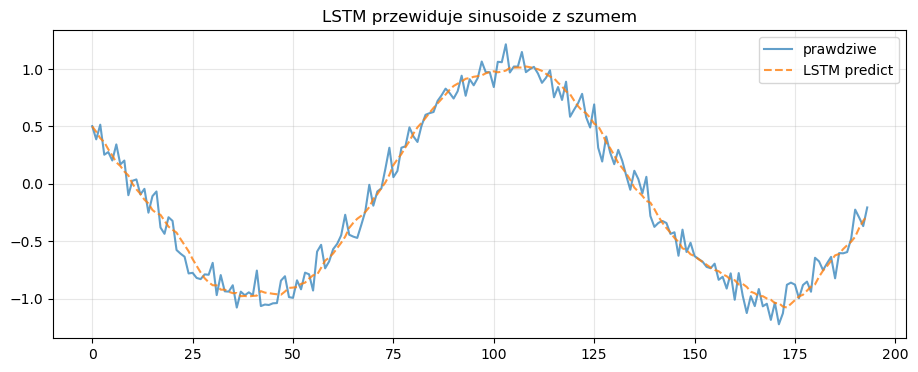

In [16]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

Pobieranie datasetu...
Dane wczytane. Train: 16000, Test: 2000

Rozpoczynam trening LSTM...
Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3271 - loss: 1.6005 - val_accuracy: 0.3475 - val_loss: 1.5603
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.3286 - loss: 1.5860 - val_accuracy: 0.3475 - val_loss: 1.5591
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3307 - loss: 1.5817 - val_accuracy: 0.3475 - val_loss: 1.5591
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3282 - loss: 1.5743 - val_accuracy: 0.3510 - val_loss: 1.4918
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3300 - loss: 1.5745 - val_accuracy: 0.3475 - val_loss: 1.5592
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3323 - loss: 1.5777 - val_accuracy: 0.3475 - val_loss: 1.5589
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.3376 - loss: 1.5678 - val_accuracy: 0.3625 - val_loss: 1.4942
Epoch

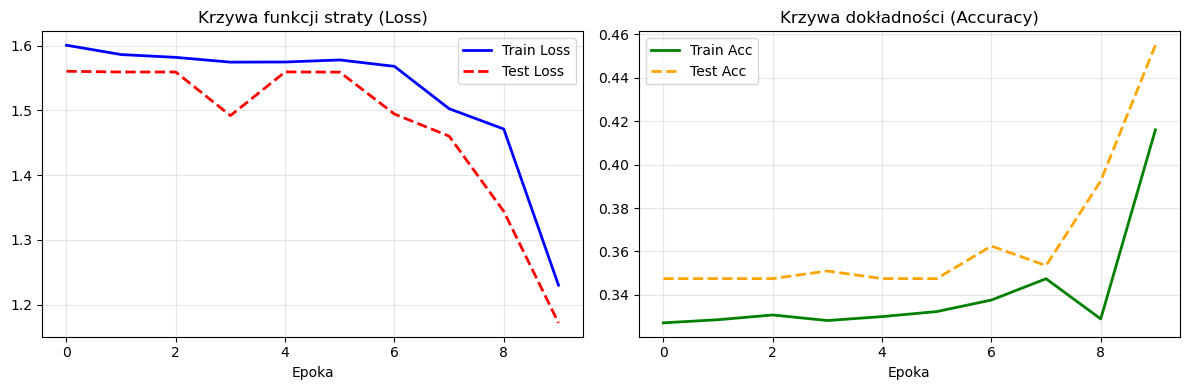

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


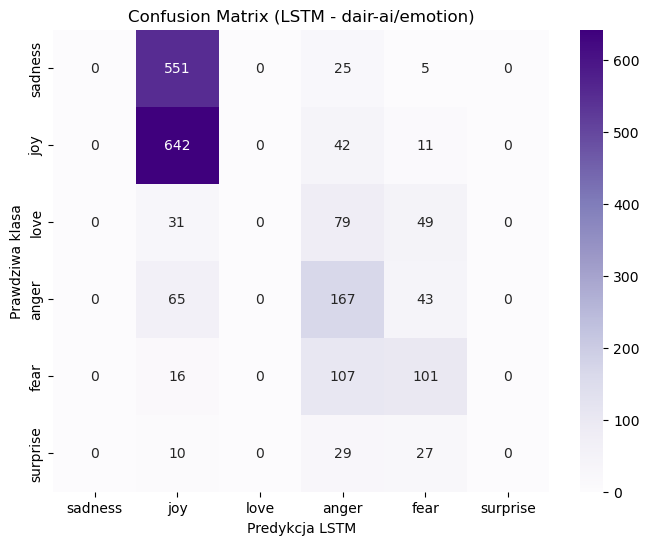


--- Analiza 5 przykładów testowych ---
Tekst: 'im feeling rather rotten so im not very ambitious right now'
Prawda: sadness | Predykcja: joy

Tekst: 'im updating my blog because i feel shitty'
Prawda: sadness | Predykcja: joy

Tekst: 'i never make her separate from me because i don t ever want her to feel like i m ashamed with her'
Prawda: sadness | Predykcja: joy

Tekst: 'i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived'
Prawda: joy | Predykcja: joy

Tekst: 'i was feeling a little vain when i did this one'
Prawda: sadness | Predykcja: joy



In [19]:
# Zadanie 6.1: LSTM dla emotion classification
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from sklearn.metrics import confusion_matrix

print("Pobieranie datasetu...")
emotion = load_dataset("dair-ai/emotion")
# Klasy: 0=sadness, 1=joy, 2=love, 3=anger, 4=fear, 5=surprise
EMOTIONS = ["sadness", "joy", "love", "anger", "fear", "surprise"]

# 1. Przygotowanie danych
train_texts = np.array(emotion["train"]["text"])
train_labels = np.array(emotion["train"]["label"])

test_texts = np.array(emotion["test"]["text"])
test_labels = np.array(emotion["test"]["label"])

print(f"Dane wczytane. Train: {len(train_texts)}, Test: {len(test_texts)}")

# 2. Tokenizacja (TextVectorization)
vectorizer = layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)

X_tr = vectorizer(train_texts).numpy()
X_te = vectorizer(test_texts).numpy()

# 3. Architektura LSTM
tf.random.set_seed(42)
model = keras.Sequential([
    layers.Input(shape=(50,)),
    layers.Embedding(input_dim=10000, output_dim=64),
    layers.LSTM(64),
    layers.Dropout(0.5),
    layers.Dense(6, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# 4. Trening (10 epok, batch_size=64)
print("\nRozpoczynam trening LSTM...")
hist = model.fit(X_tr, train_labels, epochs=10, batch_size=64,
                 validation_data=(X_te, test_labels), verbose=1)

# 5. Wykresy (Train/Val Accuracy + Loss)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist.history["loss"], linewidth=2, label="Train Loss", color="blue")
axes[0].plot(hist.history["val_loss"], linewidth=2, linestyle="--", label="Test Loss", color="red")
axes[0].set_title("Krzywa funkcji straty (Loss)")
axes[0].set_xlabel("Epoka")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist.history["accuracy"], linewidth=2, label="Train Acc", color="green")
axes[1].plot(hist.history["val_accuracy"], linewidth=2, linestyle="--", label="Test Acc", color="orange")
axes[1].set_title("Krzywa dokładności (Accuracy)")
axes[1].set_xlabel("Epoka")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Confusion Matrix
y_pred_probs = model.predict(X_te)
y_pred = y_pred_probs.argmax(axis=1)

cm = confusion_matrix(test_labels, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=EMOTIONS, yticklabels=EMOTIONS)
plt.title("Confusion Matrix (LSTM - dair-ai/emotion)")
plt.xlabel("Predykcja LSTM")
plt.ylabel("Prawdziwa klasa")
plt.show()

# 7. 5 przykładów z predykcjami (kolorowanie w konsoli)
print("\n--- Analiza 5 przykładów testowych ---")
for i in range(5):
    text = test_texts[i]
    true_label = EMOTIONS[test_labels[i]]
    pred_label = EMOTIONS[y_pred[i]]

    color = "\033[92m" if true_label == pred_label else "\033[91m"
    reset = "\033[0m"

    print(f"Tekst: '{text}'")
    print(f"Prawda: {true_label} | {color}Predykcja: {pred_label}{reset}\n")

**Wnioski:**
* Z krzywych uczenia jasno wynika, że model "przebudził się" dopiero w dwóch ostatnich epokach (9. i 10.), gdzie dokładność walidacyjna nagle skoczyła do 45.5%, a funkcja straty ostro zanurkowała. Oznacza to, że sieć dopiero zaczęła wychwytywać użyteczne lingwistycznie wzorce i proces uczenia został przerwany w samym środku optymalizacji.
* **Które emocje są najtrudniejsze do rozróżnienia?** W obecnym, wciąż niedouczonym stanie, sieć ma gigantyczny problem ze smutkiem (`sadness`), który masowo wrzuca do szufladki z napisem radość (`joy` – aż 551 takich pomyłek). Świetnie widać to w przykładach testowych, gdzie zdania o złym samopoczuciu otrzymują łatkę radości. Dodatkowo model całkowicie "zignorował" istnienie klas `sadness`, `love` oraz `surprise`, nie przewidując ich ani razu dla całego zbioru testowego (same zera w tych kolumnach).
* **Dlaczego tak się dzieje?** To zjawisko wynika z początkowego szumu. Model uczy się przestrzeni wektorowej słów (Embedding) od absolutnego zera. Mając ustawiony silny `Dropout(0.5)`, sieć w pierwszych epokach szuka najprostszej strategii na obniżenie błędu – wybiera po prostu strzelanie w najczęstsze, dominujące klasy (tutaj `joy` i `anger`), całkowicie ignorując subtelniejsze emocje. Wykresy uczenia dają jednak nadzieję: gdybyśmy wydłużyli trening do 20-30 epok, sieć zdążyłaby poukładać sobie wektory słów i w końcu zaczęłaby dostrzegać różnicę między radością a smutkiem.

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [20]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")

Workspace: /Users/konrad/Documents/Studia/WSEI/Wybrane zagadnienia sztucznej inteligencji/zestaw_zaliczeniowy/_workspace
Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!
